<div style="font-size: 27px; color: red; text-align: center; font-weight: bold;"> 
Practical 9: PMF, PDF, and CDF (Questions) </div> 

Import necessary libraries, load the 'students.csv' dataset, display a data sample, determine dataset dimensions, and view the summary statistics for both quantitative and qualitative columns.

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom
import warnings
warnings.filterwarnings("ignore")


In [81]:
df = pd.read_csv('Students.csv')
print(df.shape)
df.head()

(8239, 16)


,stud.id,name,gender,age,height,weight,religion,nc.score,semester,major,minor,score1,score2,online.tutorial,graduated,salary
0,833917,"Gonzales, Christina",Female,19,160,64.8,Muslim,1.91,1st,Political Science,Social Sciences,NaN,NaN,0,0,NaN
1,898539,"Lozano, T'Hani",Female,19,172,73.0,Other,1.56,2nd,Social Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
2,379678,"Williams, Hanh",Female,22,168,70.6,Protestant,1.24,3rd,Social Sciences,Mathematics and Statistics,45.0,46.0,0,0,NaN
3,807564,"Nem, Denzel",Male,19,183,79.7,Other,1.37,2nd,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN
4,383291,"Powell, Heather",Female,21,175,71.4,Catholic,1.46,1st,Environmental Sciences,Mathematics and Statistics,NaN,NaN,0,0,NaN


In [82]:
df.describe()

,stud.id,age,height,weight,nc.score,score1,score2,online.tutorial,graduated,salary
count,8239.000000,8239.000000,8239.000000,8239.000000,8239.000000,4892.000000,4892.000000,8239.000000,8239.000000,1753.000000
mean,548910.484525,22.541571,171.380750,72.998131,2.166481,68.164963,69.494685,0.386212,0.212769,42522.112364
std,253849.389811,6.065111,11.077529,8.635162,0.811548,14.051762,14.395251,0.486910,0.409290,10333.139906
min,110250.000000,18.000000,135.000000,51.400000,1.000000,30.000000,31.000000,0.000000,0.000000,11444.141650
25%,331222.500000,20.000000,163.000000,66.500000,1.460000,58.000000,59.000000,0.000000,0.000000,35206.541600
50%,545132.000000,21.000000,171.000000,71.800000,2.040000,70.000000,71.000000,0.000000,0.000000,41672.009750
75%,770807.500000,23.000000,180.000000,78.500000,2.780000,78.000000,80.000000,1.000000,0.000000,49372.540910
max,989901.000000,64.000000,206.000000,116.000000,4.000000,97.000000,98.000000,1.000000,1.000000,75596.793440


In [83]:
df.describe(include=['object'])

,name,gender,religion,semester,major,minor
count,8239,8239,8239,8239,8239,8239
unique,8174,2,5,7,6,6
top,"Nguyen, Brandon",Male,Catholic,1st,Environmental Sciences,Mathematics and Statistics
freq,3,4129,2797,1709,1626,1446


In [84]:
df.isna().sum()

stud.id               0
name                  0
gender                0
age                   0
height                0
weight                0
religion              0
nc.score              0
semester              0
major                 0
minor                 0
score1             3347
score2             3347
online.tutorial       0
graduated             0
salary             6486
dtype: int64

#### Q1: Draw a histogram of 'weight' and provide a short description of your observations with identifying the distribution

<Axes: xlabel='weight', ylabel='Count'>

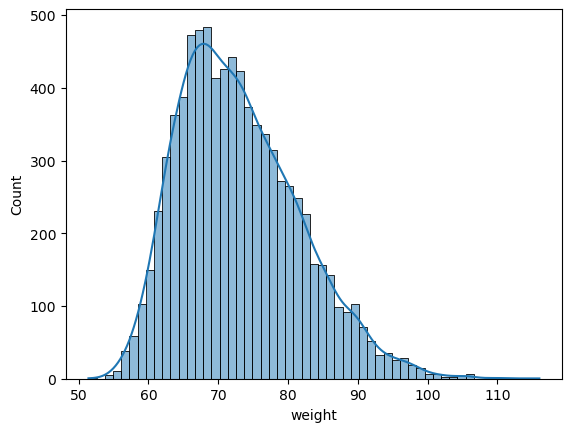

In [85]:
sns.histplot(df, x='weight', kde=True)

the histogram is right-skewed, so most students are concentrated around the central weight, while a smaller number of heavier students creates a longer tail on the right side.

#### Q2: Calculate the skewness of 'weight' and explain its significance

In [86]:
df['weight'].skew()

np.float64(0.6510039648535437)

This means mean > median and a few higher-weights pull the distribution to the right.

#### Q3: What is the probability that a student's weight is between 70 kg and 80 kg?

By CDF: P(x >= 70 and x <= 80)=F(80)-F(70)

Z score (x - mean) / std

In [98]:
z70 = (70 - df['weight'].mean()) / df['weight'].std()
z80 = (80 - df['weight'].mean()) / df['weight'].std()
F80 = norm.cdf(z80)
F70 = norm.cdf(z70)
F80 - F70

np.float64(0.4270552801321555)

#### Q4: What is the probability that a student's weight is less than 70 Kg ?

P(X<70)=F(70)

In [88]:
F70

np.float64(0.3642204178503002)

#### Q5: What is the probability that a student's weight is greater than 70 Kg ?

P(X>70)=1-F(70)

In [89]:
1 - F70


np.float64(0.6357795821496999)

#### Q6: A company produces electronic components, and their quality control process involves testing each component for defects. The defect rate for these components is 6%. The company recently received a large order for 300 components. They want to determine the probability of having a certain number of defective components in this order.

In [90]:
n = 300
p = 0.06
X = binom(n,p)

#### Question 6.1: What is the probability that exactly 10 components out of an order of 300 are defective?

P(X = 10)

In [91]:
X.pmf(10)

np.float64(0.013620614128121553)

#### Question 6.2: What is the probability that minimum 10 components out of an order of 300 are defective?


P(X >= 10) = 1 - P(x<=9)

In [92]:
1 - X.cdf(9)

np.float64(0.9868069575023568)

#### Question 6.3: What is the probability that maximum 10 components out of an order of 300 are defective?

P(X <=10)

In [93]:
X.cdf(10)

np.float64(0.026813656625764497)

#### Question 6.3: Calculate the number of components that are likely to be defective and the standard deviation of the defect probabilities for the 300 components.

Ex = np

std = sqrt(np*(1-p))

In [94]:
print(X.mean()) # expected value
print(X.std()) # std

18.0
4.113392760240627
